recherche du dossier :


Saving US Superstore data (1).xls to US Superstore data (1) (1).xls

Chargement réussi ! Voici un aperçu des données :


Text(0.5, 1.0, 'Courbe de Pareto : Contribution des clients aux ventes')

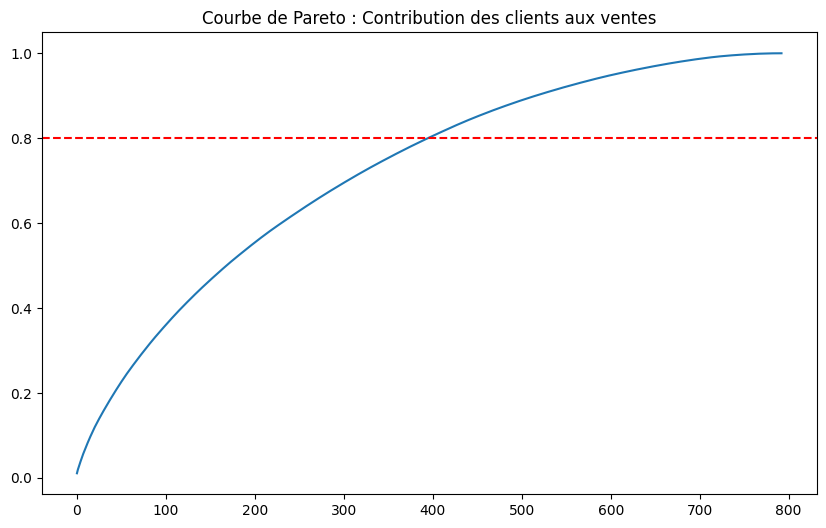

In [8]:
!pip install openpyxl
import pandas as pd
import io
from google.colab import files
print ("recherche du dossier :")
uploaded=files.upload()
file_name = list(uploaded.keys())[0]
if file_name.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
elif file_name.endswith(('.xls', '.xlsx')):
    df = pd.read_excel(io.BytesIO(uploaded[file_name]))
    print("\nChargement réussi ! Voici un aperçu des données :")
df.head()
# États avec le plus de ventes
ventes_par_etat = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

# Comparaison NY vs Californie
ny_ca = df[df['State'].isin(['New York', 'California'])]
comp_ny_ca = ny_ca.groupby('State')[['Sales', 'Profit']].sum()

# Top 20 Villes (Ventes vs Bénéfice)
top_villes_ventes = df.groupby('City')['Sales'].sum().nlargest(20)
top_villes_profit = df.groupby('City')['Profit'].sum().nlargest(20)
# Préparation des données pour le Pareto
clients = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).reset_index()
clients['Cumul_Sales'] = clients['Sales'].cumsum()
total_sales = clients['Sales'].sum()
clients['Pct_Cumul'] = clients['Cumul_Sales'] / total_sales

# Visualisation
plt.figure(figsize=(10,6))
plt.plot(clients['Pct_Cumul'].values)
plt.axhline(y=0.8, color='r', linestyle='--') # Seuil 80%
plt.title("Courbe de Pareto : Contribution des clients aux ventes")
